# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

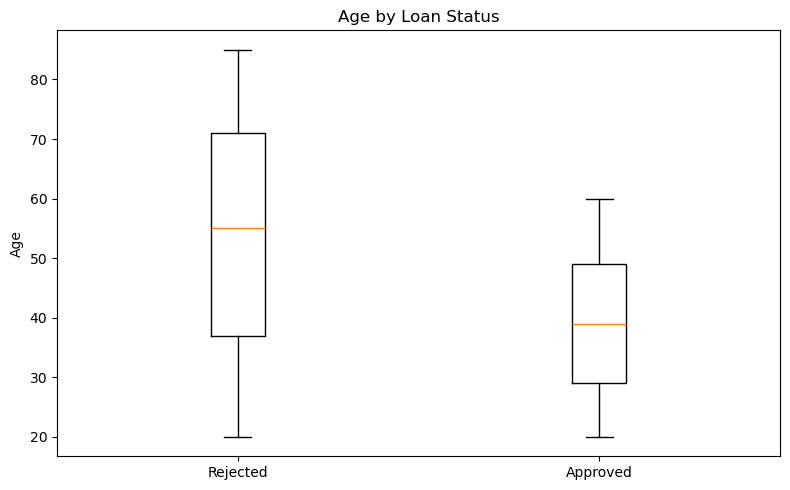

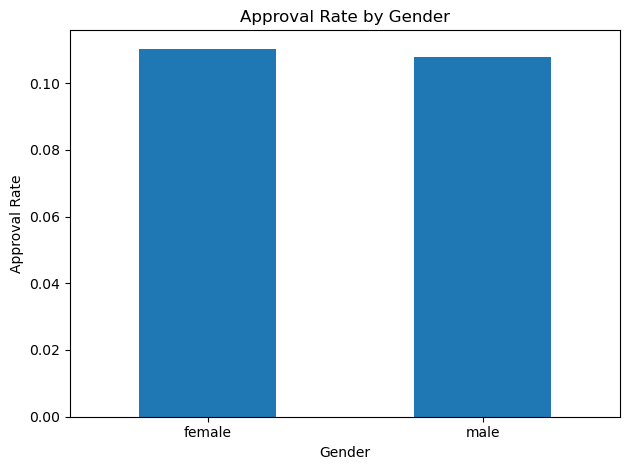

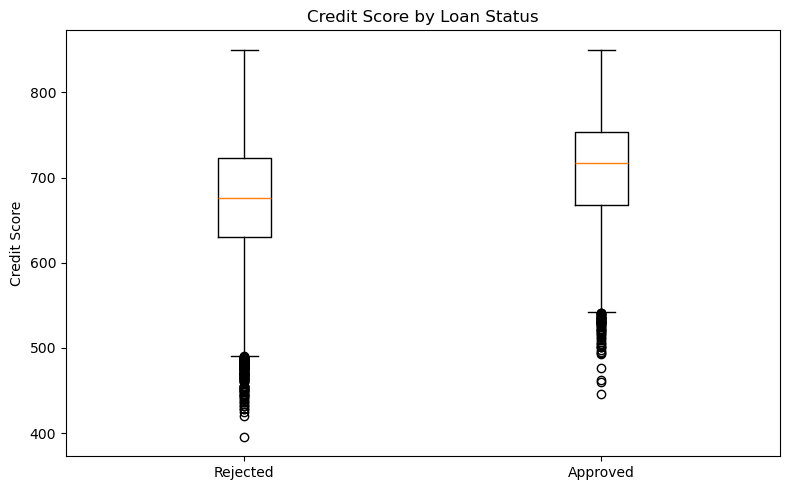

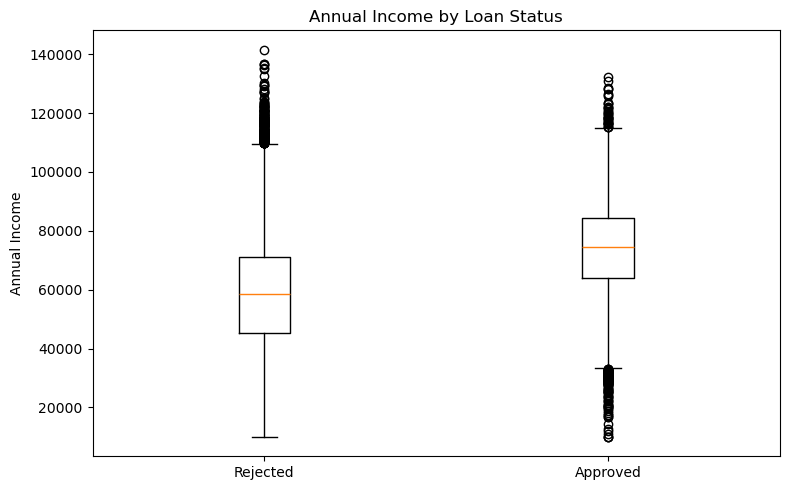

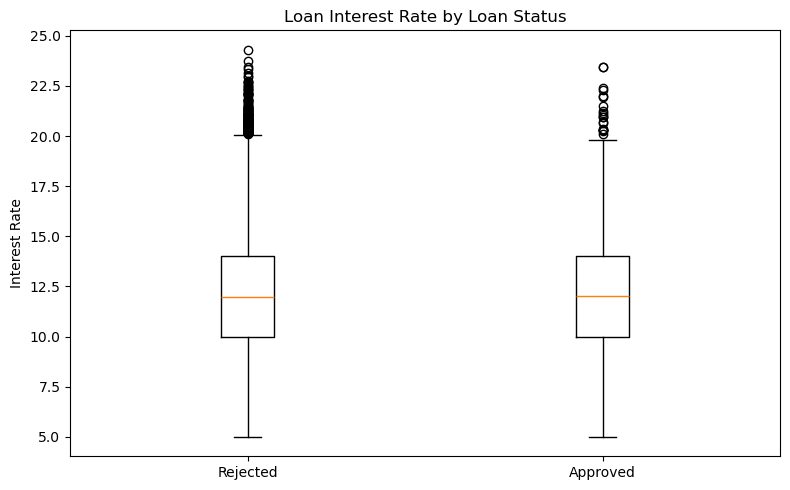

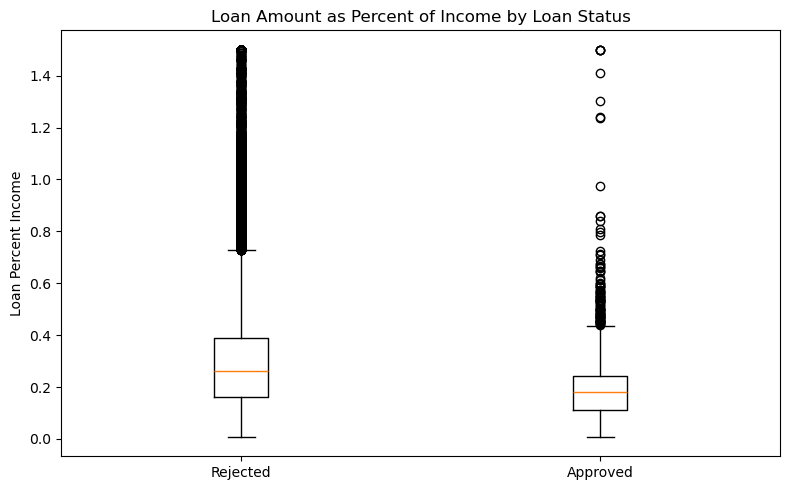

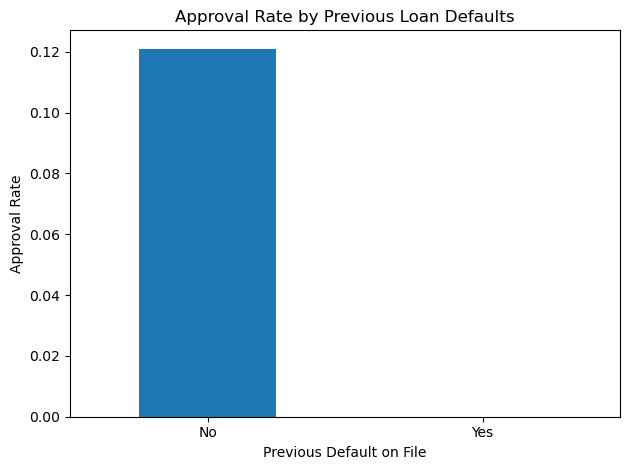

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('loan_data.csv')

approved = df[df['loan_status'] == 1]
rejected = df[df['loan_status'] == 0]

# age
plt.figure(figsize=(8, 5))
plt.boxplot([rejected['person_age'], approved['person_age']], tick_labels=['Rejected', 'Approved'])
plt.title('Age by Loan Status')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

# sex
df.groupby('person_gender')['loan_status'].mean().plot(kind='bar')
plt.title('Approval Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Approval Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# credit score
plt.figure(figsize=(8, 5))
plt.boxplot([rejected['credit_score'], approved['credit_score']], tick_labels=['Rejected', 'Approved'])
plt.title('Credit Score by Loan Status')
plt.ylabel('Credit Score')
plt.tight_layout()
plt.show()

# income
plt.figure(figsize=(8, 5))
plt.boxplot([rejected['person_income'], approved['person_income']], tick_labels=['Rejected', 'Approved'])
plt.title('Annual Income by Loan Status')
plt.ylabel('Annual Income')
plt.tight_layout()
plt.show()

# interest rate
plt.figure(figsize=(8, 5))
plt.boxplot([rejected['loan_int_rate'], approved['loan_int_rate']], tick_labels=['Rejected', 'Approved'])
plt.title('Loan Interest Rate by Loan Status')
plt.ylabel('Interest Rate')
plt.tight_layout()
plt.show()

# loan percent income
plt.figure(figsize=(8, 5))
plt.boxplot([rejected['loan_percent_income'], approved['loan_percent_income']], tick_labels=['Rejected', 'Approved'])
plt.title('Loan Amount as Percent of Income by Loan Status')
plt.ylabel('Loan Percent Income')
plt.tight_layout()
plt.show()

# previous defaults
df.groupby('previous_loan_defaults_on_file')['loan_status'].mean().plot(kind='bar')
plt.title('Approval Rate by Previous Loan Defaults')
plt.xlabel('Previous Default on File')
plt.ylabel('Approval Rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
LOAN MODEL FAIRNESS ANALYSIS — WRITTEN RESPONSES


# WHICH FEATURES SEEM TO DRIVE THE MODEL'S DECISIONS

# Credit Score seems like one of the biggest factors. The boxplot shows that approved applicants had a noticeably higher median credit score (around 717) compared to rejected ones (around 675). 
# That gap makes sense because credit score is literally designed to measure how likely someone is to pay back a loan.

# Previous Loan Defaults is probably the strongest signal in the whole dataset. 
# The bar chart shows that people with a previous default on file had basically a 0% approval rate while people with no defaults had about a 12% approval rate. If you've already failed to pay back a loan before the model is clearly not going to approve you again.

# Loan Percent Income also looks really relevant. The boxplot shows that approved applicants had a lower loan-to-income ratio (around 0.18) compared to rejected ones (around 0.26). This makes sense too because if youre asking for a loan that's a huge chunk of what you make that's a riskier bet for the bank.

# Income shows a difference too. Approved applicants had a higher median income than rejected ones. More income probably means more ability to pay back the loan so this one makes sense as a factor.

# Age actually shows a pretty big difference in the boxplot. Approved applicants had a median age of around 39 while rejected applicants had a median age of around 55. 
# This could reflect things like employment status or income stability but it could also just be the model treating older applicants differently which gets into the legal concern below.


# WHICH FEATURES SEEM UNRELATED

# Interest Rate looks basically the same for approved and rejected applicants. The boxplots are almost identical which suggests the model isn't really using interest rate to make its decision, or at least it's not a big driver.

# Gender shows almost no difference at all. Female applicants had an approval rate of about 11.0% and male applicants had 10.8%. Those are basically the same so the model doesn't appear to be discriminating based on gender.


# SHOULD THE FINANCIAL INSTITUTION BE CONCERNED ABOUT LEGAL TROUBLE

# For gender, probably not. The approval rates are nearly identical between men and women so there doesn't seem to be discrimination there based on this data.

# For age though I think there is a real concern. The boxplot shows a pretty clear difference in age between approved and rejected applicants with older people
# being rejected more. Depending on what's driving that it could be considered age discrimination which is illegal under the Age Discrimination Act. 
# Even if age isn't directly in the model as a feature, other features like income or employment experience could be acting as proxies for age and producing a biased outcome. The institution should probably look into this more carefully before going to court.